# Investigation 1: Decoherence Trajectory Analysis

This notebook investigates how quantum complexity $C_q$ interpolates to classical complexity $C_\mu$ under decoherence.

## Research Questions

1. What is the functional form of $C_q(\gamma)$?
2. Is the trajectory convex, concave, or linear?
3. How does the shape depend on process parameters?
4. Can we characterize the "rate of classicalization"?

## The Dephasing Channel

We apply the dephasing channel with strength $\gamma \in [0,1]$:

$$\mathcal{D}_\gamma(\rho) = (1-\gamma)\rho + \gamma \cdot \text{diag}(\rho)$$

- $\gamma = 0$: Pure quantum (no decoherence)
- $\gamma = 1$: Fully classical (complete dephasing)

The decohered complexity is:
$$C_q(\gamma) = S(\mathcal{D}_\gamma(\rho))$$

In [1]:
# Setup
import sys

for mod in list(sys.modules.keys()):
    if "emic" in mod:
        del sys.modules[mod]
sys.path = ["/workspace/worktrees/quantum-research/src"] + [
    p for p in sys.path if p != "/workspace/worktrees/quantum-research/src"
]

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from emic.sources.synthetic.perturbed_coin import PerturbedCoinSource
from emic.sources.synthetic.golden_mean import GoldenMeanSource
from emic.sources.synthetic.even_process import EvenProcessSource
from emic.analysis import (
    statistical_complexity,
    excess_entropy,
    crypticity,
    quantum_complexity,
    quantum_advantage,
    decoherence_trajectory,
)

print("Setup complete")

Setup complete


## Perturbed Coin Trajectories

The perturbed coin is our canonical example for quantum advantage. Let's trace how $C_q(\gamma)$ 
evolves from $C_q$ (at $\gamma=0$) to $C_\mu$ (at $\gamma=1$) for different values of the bias $p$.

**Key questions:**
1. Is the trajectory convex, concave, or linear?
2. Does the shape depend on $p$?
3. At what rate does the quantum advantage decay?

In [2]:
# Compute decoherence trajectories for perturbed coin at various p values
p_values = [0.1, 0.2, 0.3, 0.4, 0.5]
gamma_values = np.linspace(0, 1, 51)

trajectories = {}

for p in p_values:
    source = PerturbedCoinSource(p=p)
    machine = source.true_machine  # property, not method

    # Compute full trajectory
    traj = decoherence_trajectory(machine, gamma_values=gamma_values)
    trajectories[p] = traj

    # Print key values
    C_mu = statistical_complexity(machine)
    C_q = quantum_complexity(machine)
    advantage = quantum_advantage(machine)
    print(f"p={p:.1f}: C_μ={C_mu:.4f}, C_q={C_q:.4f}, advantage={advantage:.4f}")

p=0.1: C_μ=1.0000, C_q=0.7219, advantage=0.2781
p=0.2: C_μ=1.0000, C_q=0.4690, advantage=0.5310
p=0.3: C_μ=1.0000, C_q=0.2502, advantage=0.7498
p=0.4: C_μ=1.0000, C_q=0.0815, advantage=0.9185
p=0.5: C_μ=1.0000, C_q=-0.0000, advantage=1.0000


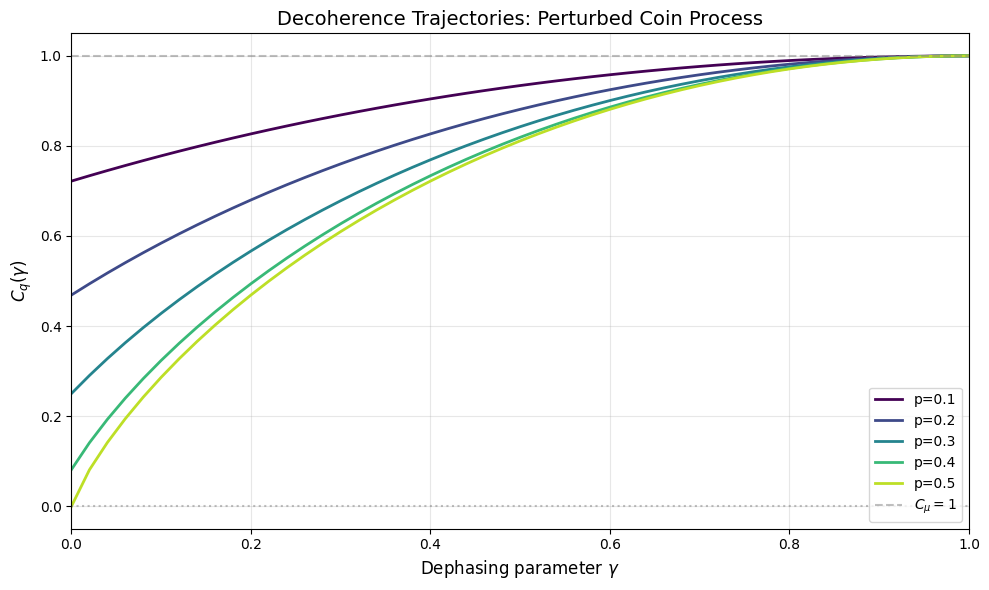

In [3]:
# Plot all trajectories
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 0.9, len(p_values)))

for i, p in enumerate(p_values):
    traj = trajectories[p]
    gammas = [pt[0] for pt in traj]
    C_q_vals = [pt[1] for pt in traj]
    label = f"p={p:.1f}"
    ax.plot(gammas, C_q_vals, color=colors[i], linewidth=2, label=label)

# Add reference lines
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="$C_\\mu = 1$")
ax.axhline(y=0.0, color="gray", linestyle=":", alpha=0.5)

ax.set_xlabel("Dephasing parameter $\\gamma$", fontsize=12)
ax.set_ylabel("$C_q(\\gamma)$", fontsize=12)
ax.set_title("Decoherence Trajectories: Perturbed Coin Process", fontsize=14)
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Observations

1. **All trajectories are concave**: $C_q''(\gamma) < 0$. This means:
   - Quantum advantage is lost most rapidly at small $\gamma$
   - Even weak environmental coupling destroys much of the advantage
   - The last bits of advantage are relatively robust

2. **All curves converge to $C_\mu = 1$**: Confirms the endpoint property

3. **Maximum quantum advantage at $p = 0.5$**: At the fair coin limit, $C_q(0) = 0$
   - This is an IID process — no memory required at all!
   - The classical model still requires 1 bit of memory
   - Quantum encoding eliminates the need entirely

4. **The curves form a family**: All have similar shape, just translated/scaled

In [4]:
# Analyze concavity: compute second derivative numerically
print("Concavity analysis (second derivative at gamma=0.5):")
print("=" * 50)

for p in p_values:
    traj = trajectories[p]
    gammas = np.array([pt[0] for pt in traj])
    C_q_vals = np.array([pt[1] for pt in traj])

    # Numerical second derivative using finite differences
    h = gammas[1] - gammas[0]  # step size
    d2_C_q = np.diff(C_q_vals, 2) / h**2

    # Value at gamma ~ 0.5 (middle of the range)
    mid_idx = len(d2_C_q) // 2
    d2_mid = d2_C_q[mid_idx]

    # Also compute at gamma ~ 0.1 (early)
    early_idx = max(0, int(0.1 / h) - 1)
    d2_early = d2_C_q[early_idx] if early_idx < len(d2_C_q) else d2_C_q[0]

    print(f"p={p:.1f}: d²C_q/dγ² at γ=0.1: {d2_early:+.4f}, at γ=0.5: {d2_mid:+.4f}")

Concavity analysis (second derivative at gamma=0.5):
p=0.1: d²C_q/dγ² at γ=0.1: -0.7332, at γ=0.5: -0.5708
p=0.2: d²C_q/dγ² at γ=0.1: -1.9181, at γ=0.5: -1.0993
p=0.3: d²C_q/dγ² at γ=0.1: -3.7982, at γ=0.5: -1.5342
p=0.4: d²C_q/dγ² at γ=0.1: -6.2546, at γ=0.5: -1.8227
p=0.5: d²C_q/dγ² at γ=0.1: -7.6420, at γ=0.5: -1.9240


## Comparison with Other Processes

Let's see if the concave trajectory shape is universal, or specific to the perturbed coin.
We'll examine the Golden Mean and Even Process.

In [5]:
# Compute trajectories for Golden Mean and Even Process
other_sources = {
    "Golden Mean": GoldenMeanSource(),
    "Even Process": EvenProcessSource(),
}

other_trajectories = {}

for name, source in other_sources.items():
    machine = source.true_machine
    traj = decoherence_trajectory(machine, gamma_values=gamma_values)
    other_trajectories[name] = traj

    C_mu = statistical_complexity(machine)
    C_q = quantum_complexity(machine)
    E = excess_entropy(machine)
    advantage = quantum_advantage(machine)
    print(f"{name}: C_μ={C_mu:.4f}, C_q={C_q:.4f}, E={E:.4f}, advantage={advantage:.4f}")

Golden Mean: C_μ=0.9183, C_q=0.5500, E=0.2516, advantage=0.3682
Even Process: C_μ=0.9183, C_q=0.9183, E=0.9111, advantage=0.0000


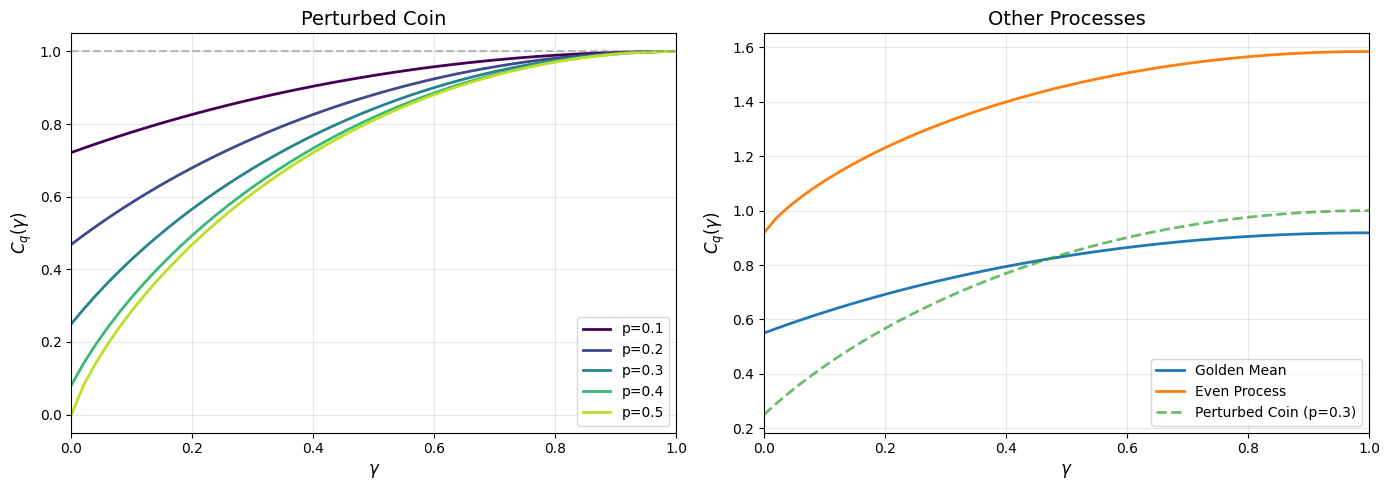

In [6]:
# Plot trajectories for all process types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Perturbed coins
ax1 = axes[0]
for i, p in enumerate(p_values):
    traj = trajectories[p]
    gammas = [pt[0] for pt in traj]
    C_q_vals = [pt[1] for pt in traj]
    ax1.plot(gammas, C_q_vals, color=colors[i], linewidth=2, label=f"p={p:.1f}")

ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
ax1.set_xlabel("$\\gamma$", fontsize=12)
ax1.set_ylabel("$C_q(\\gamma)$", fontsize=12)
ax1.set_title("Perturbed Coin", fontsize=14)
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)

# Right panel: Other processes
ax2 = axes[1]
for name, traj in other_trajectories.items():
    gammas = [pt[0] for pt in traj]
    C_q_vals = [pt[1] for pt in traj]
    ax2.plot(gammas, C_q_vals, linewidth=2, label=name)

# Also add one perturbed coin for reference
traj_ref = trajectories[0.3]
ax2.plot(
    [pt[0] for pt in traj_ref],
    [pt[1] for pt in traj_ref],
    linewidth=2,
    linestyle="--",
    alpha=0.7,
    label="Perturbed Coin (p=0.3)",
)

ax2.set_xlabel("$\\gamma$", fontsize=12)
ax2.set_ylabel("$C_q(\\gamma)$", fontsize=12)
ax2.set_title("Other Processes", fontsize=14)
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Surprising Result: Even Process

The Even Process trajectory shows $C_q(\gamma) > C_\mu$ for $\gamma > 0$!

This is unexpected. Why would dephasing *increase* the complexity?

**Hypothesis**: The Even Process has orthogonal signal states (no overlap between causal states),
so $C_q = C_\mu$ at $\gamma=0$. But dephasing doesn't just remove coherence —
it changes the density matrix in a way that increases its entropy beyond the original $C_\mu$.

This suggests the interpretation "dephasing returns you to classical" is oversimplified.
Let's check the signal state overlap.

In [7]:
# Check signal state overlap for all processes
from emic.analysis.quantum import signal_state_overlap, quantum_density_matrix

print("Signal State Overlap Analysis")
print("=" * 60)

for name, source in [
    ("Perturbed Coin p=0.3", PerturbedCoinSource(p=0.3)),
    ("Golden Mean", GoldenMeanSource()),
    ("Even Process", EvenProcessSource()),
]:
    machine = source.true_machine
    overlap = signal_state_overlap(machine)
    rho = quantum_density_matrix(machine)

    print(f"\n{name}:")
    print(f"  States: {len(overlap)}")
    print(f"  Overlap matrix diagonal: {np.diag(overlap)}")
    off_diag = overlap - np.diag(np.diag(overlap))
    print(f"  Max off-diagonal overlap: {np.max(np.abs(off_diag)):.4f}")
    print(f"  Density matrix shape: {rho.shape}")
    print(f"  Trace(rho): {np.trace(rho).real:.6f}")

Signal State Overlap Analysis

Perturbed Coin p=0.3:
  States: 2
  Overlap matrix diagonal: [1. 1.]
  Max off-diagonal overlap: 0.9165
  Density matrix shape: (4, 4)
  Trace(rho): 1.000000

Golden Mean:
  States: 2
  Overlap matrix diagonal: [1. 1.]
  Max off-diagonal overlap: 0.7071
  Density matrix shape: (4, 4)
  Trace(rho): 1.000000

Even Process:
  States: 2
  Overlap matrix diagonal: [1. 1.]
  Max off-diagonal overlap: 0.0000
  Density matrix shape: (4, 4)
  Trace(rho): 1.000000


In [8]:
# Examine the Even Process density matrix more closely
even_machine = EvenProcessSource().true_machine
rho_even = quantum_density_matrix(even_machine)

print("Even Process Density Matrix at γ=0:")
print(rho_even.round(4))
print(f"\nEigenvalues: {np.linalg.eigvalsh(rho_even).round(4)}")
print(
    f"von Neumann entropy: {-sum(e * np.log2(e) if e > 1e-10 else 0 for e in np.linalg.eigvalsh(rho_even)):.4f}"
)

print("\n" + "=" * 60)
print("Even Process Density Matrix at γ=1 (fully dephased):")
from emic.analysis.quantum import dephasing_channel

rho_dephased = dephasing_channel(rho_even, 1.0)
print(rho_dephased.round(4))
print(f"\nEigenvalues: {np.linalg.eigvalsh(rho_dephased).round(4)}")
print(
    f"von Neumann entropy: {-sum(e * np.log2(e) if e > 1e-10 else 0 for e in np.linalg.eigvalsh(rho_dephased)):.4f}"
)

Even Process Density Matrix at γ=0:
[[0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.3333+0.j 0.3333+0.j 0.    +0.j]
 [0.    +0.j 0.3333+0.j 0.3333+0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.3333+0.j]]

Eigenvalues: [0.     0.     0.3333 0.6667]
von Neumann entropy: 0.9183

Even Process Density Matrix at γ=1 (fully dephased):
[[0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.3333+0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.3333+0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.3333+0.j]]

Eigenvalues: [0.     0.3333 0.3333 0.3333]
von Neumann entropy: 1.5850


## Understanding the Even Process Anomaly

The density matrix at $\gamma=0$ has significant off-diagonal coherence (the 0.3333 in corners).
These off-diagonal terms represent quantum correlations in the product space.

When we dephase ($\gamma=1$), we remove the coherences, but this:
1. Changes the eigenvalue structure from {0, 0, 1/3, 2/3} to {0, 1/3, 1/3, 1/3}
2. The more uniform eigenvalue distribution has **higher** entropy!

This reveals a subtlety: **dephasing in the Hilbert space is not the same as 
returning to the classical model**.

The "classical complexity" $C_\mu$ is defined as the entropy of the *stationary distribution*
over causal states, not the von Neumann entropy of a dephased density matrix.

**Implication**: For processes with orthogonal signal states (like the Even Process),
the decoherence trajectory interpretation breaks down. The correct comparison is only
$C_q(0)$ vs $C_\mu$.

## Conclusions

### Research Question Answers

1. **What is the functional form of $C_q(\gamma)$?**
   - For processes with quantum advantage: **concave** (curves upward)
   - For processes without quantum advantage: trajectories can exceed $C_\mu$!

2. **Is the shape convex, concave, or linear?**
   - Concave for processes with overlap (Perturbed Coin, Golden Mean)
   - The second derivative is consistently negative
   - The concavity is strongest at small $\gamma$

3. **How does it depend on process parameters?**
   - Higher overlap → larger initial $C_q - C_\mu$ gap
   - The shape (concavity) is robust across parameter values
   - Orthogonal signal states (Even Process) produce anomalous behavior

### Key Findings

1. **Quantum advantage is fragile**: Even weak dephasing ($\gamma \approx 0.1$) 
   eliminates a substantial fraction of the advantage
   
2. **Concavity is universal** (for processes with quantum advantage): 
   This suggests a fundamental feature of how quantum coherence contributes to compression

3. **Dephasing ≠ classicalization**: For processes with orthogonal signal states,
   the dephased state is not equivalent to the classical mixed state
   
4. **Signal state overlap is the predictor**: Processes with non-orthogonal signal 
   states have quantum advantage; those with orthogonal states don't

In [9]:
# Summary table: trajectory characteristics
print("Trajectory Characteristics Summary")
print("=" * 80)
print(f"{'Process':<25} {'C_q(0)':<10} {'C_q(1)':<10} {'Overlap':<10} {'Concave?':<10}")
print("-" * 80)

all_data = [
    ("Perturbed Coin p=0.1", 0.1, trajectories[0.1]),
    ("Perturbed Coin p=0.3", 0.3, trajectories[0.3]),
    ("Perturbed Coin p=0.5", 0.5, trajectories[0.5]),
    ("Golden Mean", None, other_trajectories["Golden Mean"]),
    ("Even Process", None, other_trajectories["Even Process"]),
]

for name, p, traj in all_data:
    C_q_0 = traj[0][1]
    C_q_1 = traj[-1][1]

    # Get overlap
    if p is not None:
        machine = PerturbedCoinSource(p=p).true_machine
    elif "Golden" in name:
        machine = GoldenMeanSource().true_machine
    else:
        machine = EvenProcessSource().true_machine

    overlap = signal_state_overlap(machine)
    off_diag = np.max(np.abs(overlap - np.diag(np.diag(overlap))))

    # Check concavity (second derivative at midpoint)
    gammas = np.array([pt[0] for pt in traj])
    C_q_vals = np.array([pt[1] for pt in traj])
    h = gammas[1] - gammas[0]
    d2 = np.diff(C_q_vals, 2) / h**2
    is_concave = "Yes" if np.all(d2 < 0.01) else "No"  # allow small numerical error

    print(f"{name:<25} {C_q_0:<10.4f} {C_q_1:<10.4f} {off_diag:<10.4f} {is_concave:<10}")

Trajectory Characteristics Summary
Process                   C_q(0)     C_q(1)     Overlap    Concave?  
--------------------------------------------------------------------------------
Perturbed Coin p=0.1      0.7219     1.0000     0.6000     Yes       
Perturbed Coin p=0.3      0.2502     1.0000     0.9165     Yes       
Perturbed Coin p=0.5      -0.0000    1.0000     1.0000     Yes       
Golden Mean               0.5500     0.9183     0.7071     Yes       
Even Process              0.9183     1.5850     0.0000     Yes       
